# Supplementary Figure S40: five-dataset LOTO benchmark

Load the compact target-level results, recalculate the matched ratios, and reproduce the manuscript figure.

## Reproduction route

This route states where the plotted values begin, how the upstream analysis is
run when it is available, and what this notebook does not recalculate.

In [1]:
from CytoBridge.results import describe_figure_workflow

route = describe_figure_workflow('loto-benchmark')
{
    key: route[key]
    for key in (
        "paper_location",
        "mode",
        "starts_from",
        "upstream_entry",
        "upstream_command",
        "figure_command",
        "scope",
    )
}

{'paper_location': 'Supplementary Figure S40',
 'mode': 'numeric-redraw',
 'starts_from': 'Packaged target-level LOTO means and native-support records.',
 'upstream_entry': 'scripts/spatiotemporal_benchmark/README.md',
 'upstream_command': 'python scripts/spatiotemporal_benchmark/run_unified_benchmark.py --help',
 'figure_command': 'cytobridge figure loto-benchmark --output-dir outputs/loto_benchmark',
 'scope': 'Redraws S40. Method fitting and projection evaluation are not rerun by the figure command.'}

## Imports and configuration

In [2]:
from pathlib import Path

from IPython.display import Image, display
import numpy as np
import pandas as pd

from CytoBridge.results import load_loto_benchmark, plot_loto_benchmark
from CytoBridge.results.loto_benchmark import (
    compute_paired_loto_ratios,
    summarize_loto_ratios,
    write_loto_benchmark_tables,
)

output_dir = Path("outputs") / "loto_benchmark"
output_dir.mkdir(parents=True, exist_ok=True)

## Load processed results

In [3]:
data = load_loto_benchmark()
display(data.target_means.head(12))
{
    "target_mean_rows": len(data.target_means),
    "native_support_rows": len(data.native_support),
    "datasets": data.protocol["datasets"],
}

,dataset,target,method,display_name,space,sliced_w2,projection_sd,n_projection_repeats
0,zebrafish,1,CytoBridge-0.015,CytoBridge,joint,0.058313,0.000896,5
1,zebrafish,1,CytoBridge-0.015,CytoBridge,state,0.056534,0.001436,5
2,zebrafish,1,CytoBridge-0.015,CytoBridge,spatial,0.049454,0.000181,5
3,zebrafish,1,stvcr,stVCR,joint,0.110448,0.000825,5
4,zebrafish,1,stvcr,stVCR,state,0.106451,0.001342,5
5,zebrafish,1,stvcr,stVCR,spatial,0.189775,0.000802,5
6,zebrafish,1,moscot,MOSCOT,joint,0.082304,0.000488,5
7,zebrafish,1,moscot,MOSCOT,state,0.085305,0.001300,5
8,zebrafish,1,moscot,MOSCOT,spatial,0.084715,0.000303,5
9,zebrafish,1,paste,PASTE,joint,0.077584,0.000578,5


{'target_mean_rows': 231,
 'native_support_rows': 99,
 'datasets': ['zebrafish', 'mosta', 'arista', 'admouse', 'chicken_heart']}

## Recalculate panel data

Each target-level value is the mean of five projection repeats. Within each repeat, applicable methods use the same 1,024 directions for that dataset–target–space cell. Ratios are calculated in matched dataset–target–space cells and then averaged with equal cell weight within each dataset and method.

In [4]:
projection = data.protocol["projection"]
method_spaces = pd.DataFrame(
    [
        {
            "method": data.protocol["display_names"][method],
            "spaces": ", ".join(data.protocol["spaces_by_method"][method]),
        }
        for method in data.protocol["method_order"]
    ]
)
display(
    {
        "projection_repeats": projection["repeats_per_dataset_target_space"],
        "directions_per_repeat": projection["directions_per_repeat"],
        "initial_source_roster": data.protocol["support"]["initial_source_roster_n"],
        "target_size_resampling": data.protocol["support"]["target_size_resampling"],
    },
    method_spaces,
)

paired_ratios = compute_paired_loto_ratios(data.target_means)
dataset_summary = summarize_loto_ratios(paired_ratios)
display(paired_ratios.head(12), dataset_summary)

{'projection_repeats': 5,
 'directions_per_repeat': 1024,
 'initial_source_roster': 5000,
 'target_size_resampling': False}

,method,spaces
0,CytoBridge,"joint, spatial, state"
1,stVCR,"joint, spatial, state"
2,MOSCOT,"joint, spatial, state"
3,PASTE,"joint, spatial, state"
4,Spateo,"joint, spatial, state"
5,Random interpolation,"joint, spatial, state"
6,MIOFlow,state
7,STORIES,state
8,Waddington-OT,state


,method,display_name,dataset,target,space,cytobridge_sliced_w2,method_sliced_w2,method_to_cytobridge_ratio
0,stvcr,stVCR,zebrafish,1,joint,0.058313,0.110448,1.894050
1,stvcr,stVCR,zebrafish,1,state,0.056534,0.106451,1.882957
2,stvcr,stVCR,zebrafish,1,spatial,0.049454,0.189775,3.837419
3,stvcr,stVCR,zebrafish,2,joint,0.056431,0.124771,2.211034
4,stvcr,stVCR,zebrafish,2,state,0.056856,0.116384,2.046981
5,stvcr,stVCR,zebrafish,2,spatial,0.044071,0.299843,6.803604
6,stvcr,stVCR,zebrafish,3,joint,0.061056,0.070883,1.160942
7,stvcr,stVCR,zebrafish,3,state,0.062311,0.071264,1.143675
8,stvcr,stVCR,zebrafish,3,spatial,0.058733,0.134114,2.283478
9,stvcr,stVCR,mosta,1,joint,0.051437,0.047729,0.927903


,method,display_name,dataset,relative_sliced_w2,median_relative_sliced_w2,n_paired_comparisons
0,mioflow,MIOFlow,admouse,1.438249,1.438249,1
1,mioflow,MIOFlow,arista,1.206811,1.120990,3
2,mioflow,MIOFlow,chicken_heart,0.960023,0.960023,2
3,mioflow,MIOFlow,mosta,1.228673,1.228673,2
4,mioflow,MIOFlow,zebrafish,1.204146,1.380377,3
5,moscot,MOSCOT,admouse,1.755581,1.829013,3
6,moscot,MOSCOT,arista,1.189000,1.177058,9
7,moscot,MOSCOT,chicken_heart,1.099076,1.103960,6
8,moscot,MOSCOT,mosta,1.120013,1.136170,6
9,moscot,MOSCOT,zebrafish,1.332576,1.411414,9


## Inspect method-native support

The support table records the 5,000-point initial roster, the method-native final support, normalized predicted weights, and the absence of target-size resampling.

In [5]:
support_columns = [
    "dataset",
    "target",
    "display_name",
    "initial_source_roster_n",
    "native_output_n",
    "sliced_w2_predicted_weights",
    "target_size_resampling",
]
display(
    data.native_support.loc[
        data.native_support["method"].isin(["stvcr", "mioflow"]),
        support_columns,
    ].head(12)
)

,dataset,target,display_name,initial_source_roster_n,native_output_n,sliced_w2_predicted_weights,target_size_resampling
1,zebrafish,1,stVCR,5000,21,normalized_before_metric,False
6,zebrafish,1,MIOFlow,5000,5000,normalized_before_metric,False
10,zebrafish,2,stVCR,5000,30234,normalized_before_metric,False
15,zebrafish,2,MIOFlow,5000,5000,normalized_before_metric,False
19,zebrafish,3,stVCR,5000,5254,normalized_before_metric,False
24,zebrafish,3,MIOFlow,5000,5000,normalized_before_metric,False
28,mosta,1,stVCR,5000,1461,normalized_before_metric,False
33,mosta,1,MIOFlow,5000,5000,normalized_before_metric,False
37,mosta,2,stVCR,5000,24728,normalized_before_metric,False
42,mosta,2,MIOFlow,5000,5000,normalized_before_metric,False


## Render and save the figure

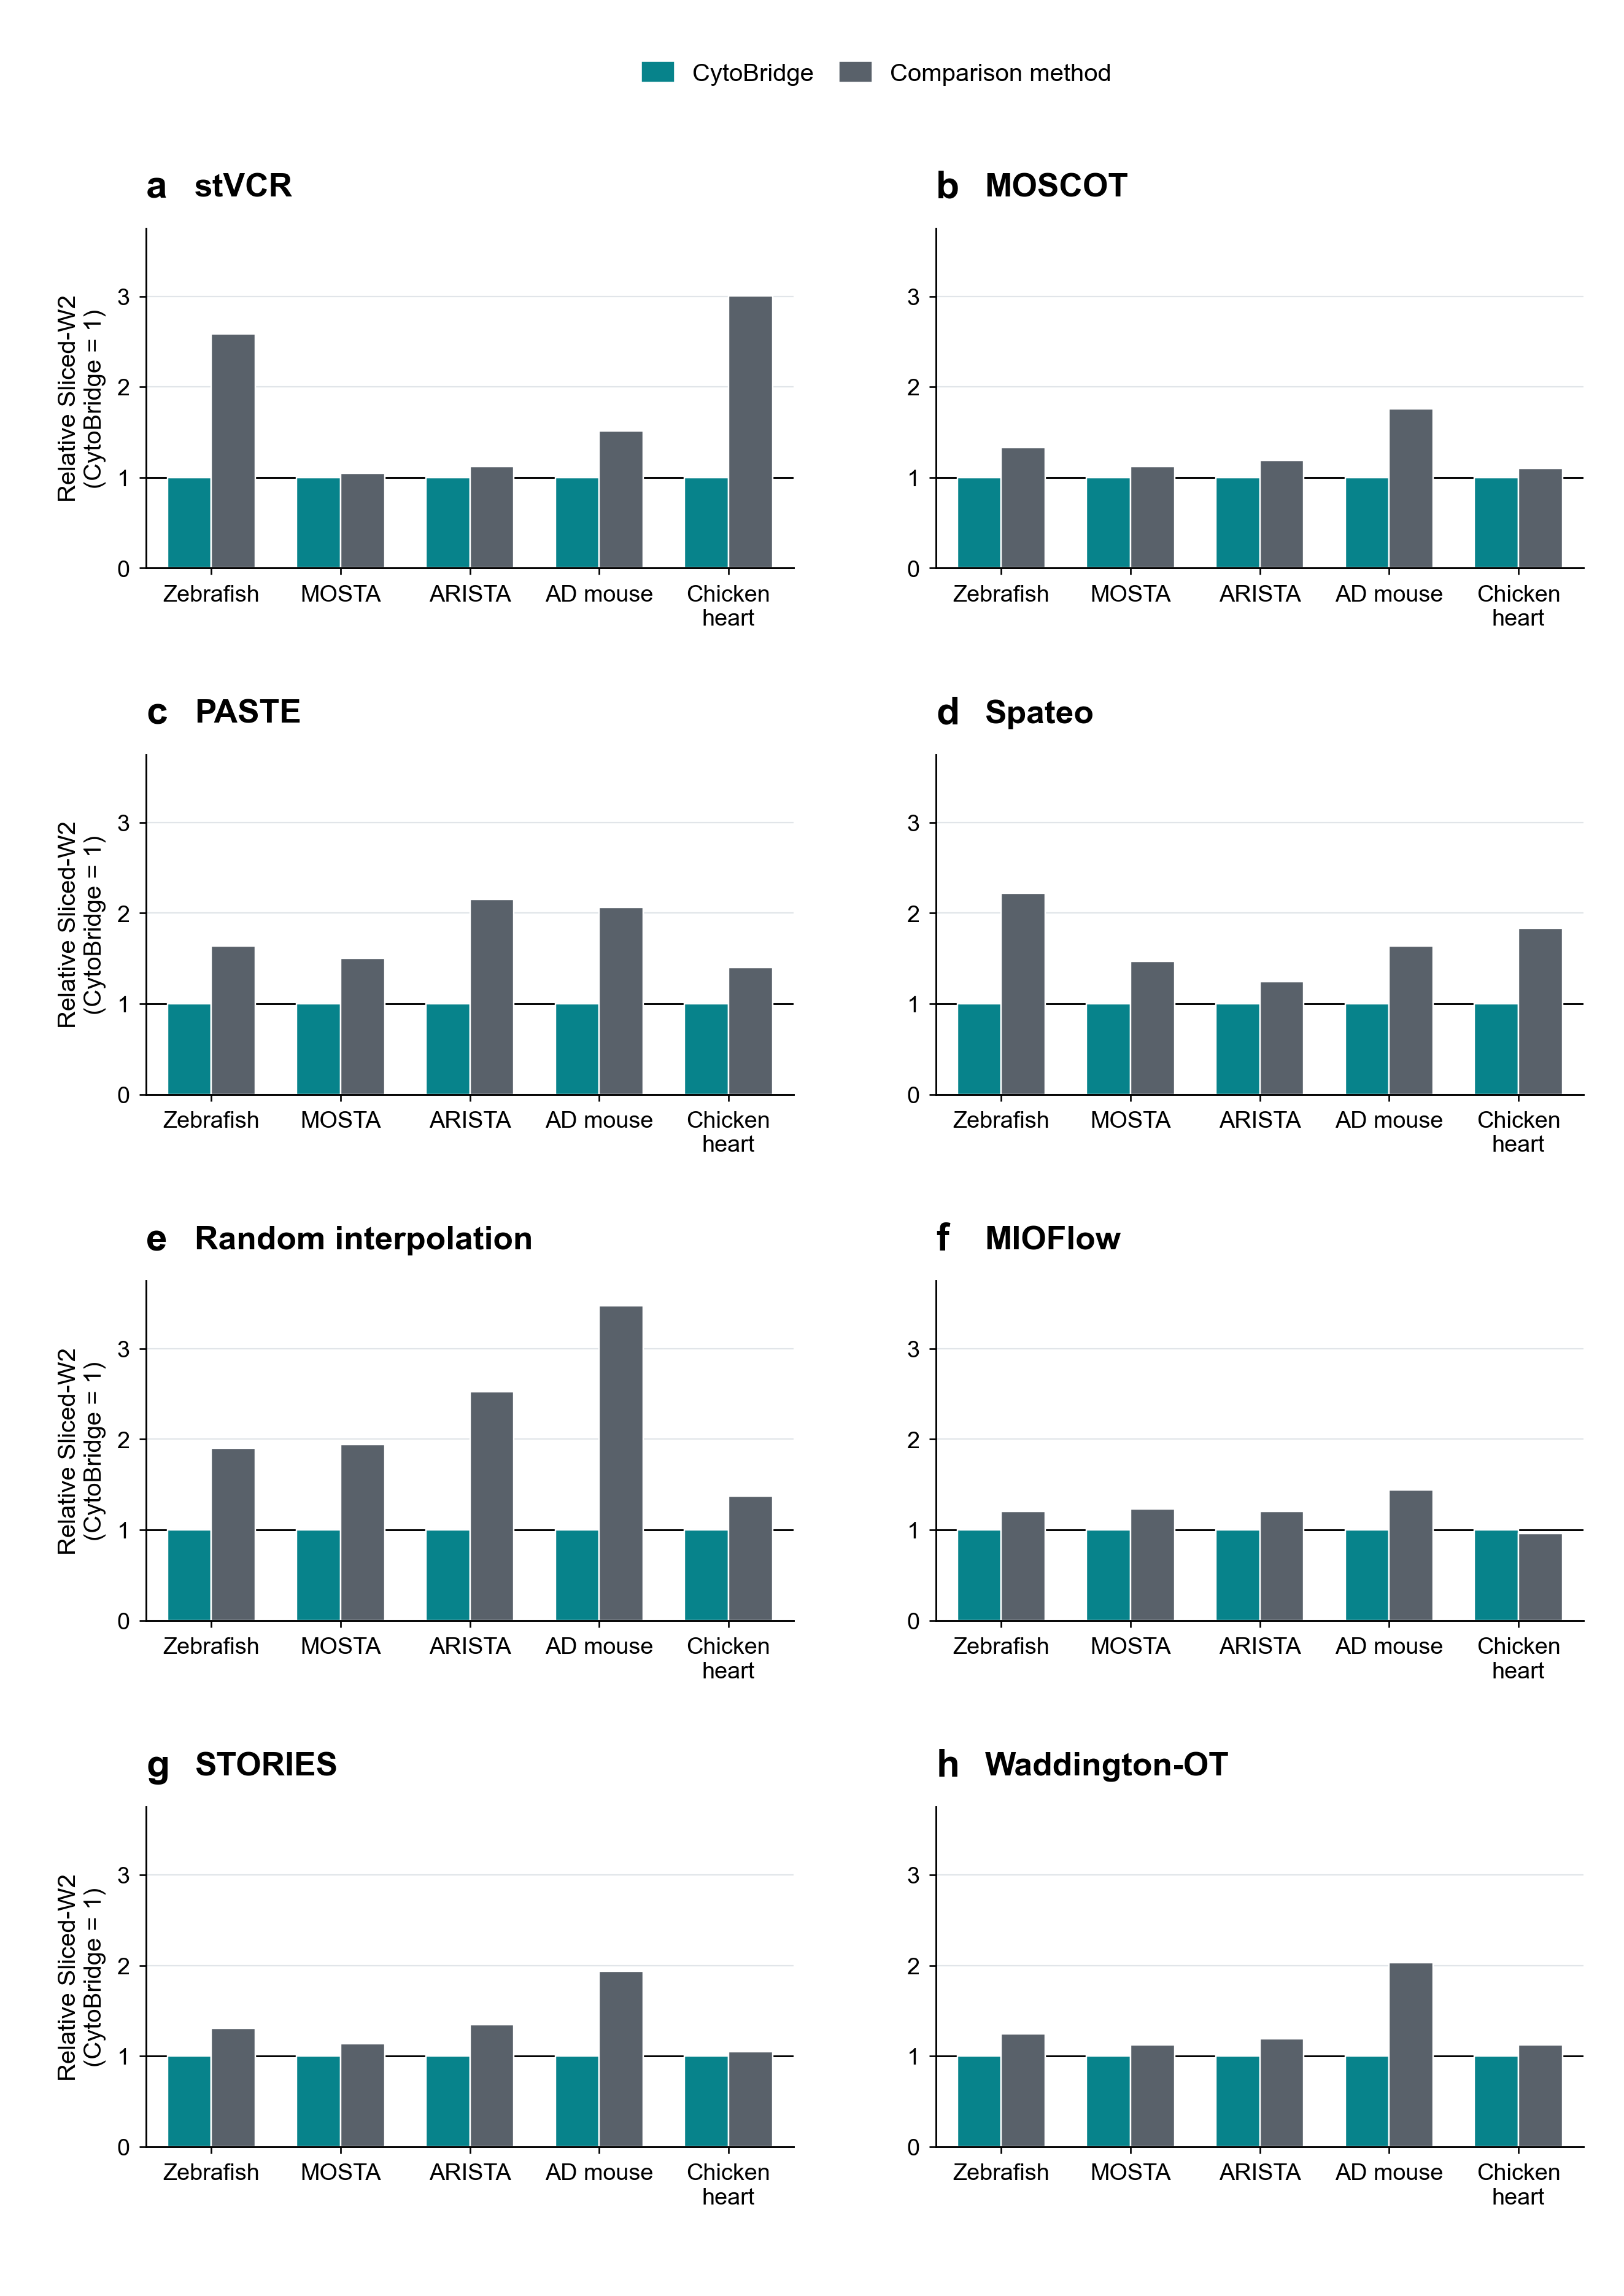

In [6]:
table_paths = write_loto_benchmark_tables(data, output_dir)
pdf_path, png_path = plot_loto_benchmark(data, output_dir)
display(Image(filename=str(png_path), width=700))

## Check outputs

In [7]:
{
    "paired_ratio_rows": len(paired_ratios),
    "dataset_summary_rows": len(dataset_summary),
    "paired_ratio_values_match": np.allclose(
        paired_ratios["method_to_cytobridge_ratio"],
        data.paired_ratios["method_to_cytobridge_ratio"],
    ),
    "dataset_summary_values_match": np.allclose(
        dataset_summary["relative_sliced_w2"],
        data.dataset_summary["relative_sliced_w2"],
    ),
    "tables": {name: path.is_file() for name, path in table_paths.items()},
    "pdf": pdf_path.is_file(),
    "png": png_path.is_file(),
}

{'paired_ratio_rows': 198,
 'dataset_summary_rows': 40,
 'paired_ratio_values_match': True,
 'dataset_summary_values_match': True,
 'tables': {'paired_ratios': True, 'dataset_summary': True},
 'pdf': True,
 'png': True}

## Upstream analysis and API

The command-line entry is `scripts/results/plot_loto_benchmark.py`. The reader API is in `CytoBridge/results/loto_benchmark.py`. Projection-level evaluation is upstream of the packaged target means.